In [1]:
!rm -f rtp*.so
!python -m numpy.f2py -c rtp.f90 -m rtp

/home/jayarshi/miniconda3/envs/oqs/lib/python3.11/site-packages/numpy/f2py/f2py2e.py:719: VisibleDeprecationWarning: distutils has been deprecated since NumPy 1.26.xUse the Meson backend instead, or generate wrapperswithout -c and use a custom build script
  builder = build_backend(
running build
running config_cc
INFO: unifing config_cc, config, build_clib, build_ext, build commands --compiler options
running config_fc
INFO: unifing config_fc, config, build_clib, build_ext, build commands --fcompiler options
running build_src
INFO: build_src
INFO: building extension "rtp" sources
INFO: f2py options: []
INFO: f2py:> /tmp/tmpwlsr9ucc/src.linux-x86_64-3.11/rtpmodule.c
creating /tmp/tmpwlsr9ucc/src.linux-x86_64-3.11
Reading fortran codes...
	Reading file 'rtp.f90' (format:free)
Post-processing...
	Block: rtp
			Block: rtp_store
In: :rtp:rtp.f90:rtp_store
param_eval: got "eval() arg 1 must be a string, bytes or code object" on 4
Applying post-processing hooks...
  character_backward_compat

In [2]:
import rtp
print(rtp.__file__)

/home/jayarshi/Github/Public/active-particle-simulations/f2py_interfaces/rtp.cpython-311-x86_64-linux-gnu.so


In [4]:
import rtp
print(rtp.rtp_store.__doc__)

xstore,times = rtp_store(g,d2,dt,ens,v0,n,ntimes,xstore,times)

Wrapper for ``rtp_store``.

Parameters
----------
g : input float
d2 : input float
dt : input float
ens : input int
v0 : input float
n : input int
ntimes : input int
xstore : input rank-2 array('f') with bounds (ens,ntimes)
times : input rank-1 array('f') with bounds (ntimes)

Returns
-------
xstore : rank-2 array('f') with bounds (ens,ntimes)
times : rank-1 array('f') with bounds (ntimes)



In [5]:
import numpy as np
import matplotlib.pyplot as plt

g = 0.05
d2 = 0.0
dt = 0.01
tmax = 300
v0 = 1.0

ens = 10000
ntimes = 150
n = ntimes * int(tmax / dt / ntimes)

xstore = np.zeros((ens, ntimes), dtype=np.float32)
times = np.zeros(ntimes, dtype=np.float32)

xstore,times = rtp.rtp_store(g,d2,dt,ens,v0,n,ntimes,xstore,times)

avgx2 = np.mean(xstore**2, axis=0)

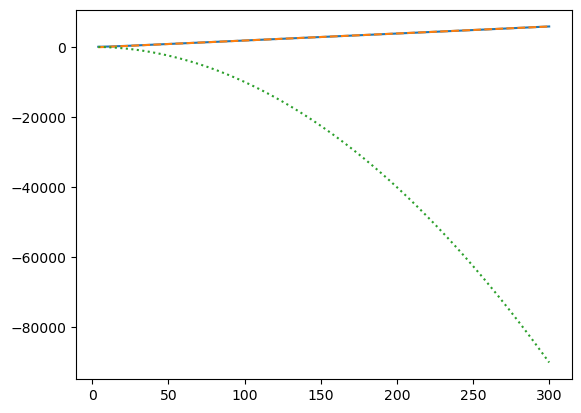

In [10]:


plt.plot(times[1:], avgx2[1:], label=r"$\langle x^2 \rangle$")
plt.plot(times[1:], (d2+v0**2/g)*times[1:]-v0**2/2/g**2, "--", label="t")
plt.plot(times[1:], d2*times[1:]-v0**2*times[1:]**2, ":", label=r"$t^2$")

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots()

xmin, xmax = np.min(xstore), np.max(xstore)

def update(frame):
    ax.clear()
    ax.hist(xstore[:, frame], bins=100, density=True, histtype="step")
    ax.set_xlim(xmin, xmax)
    ax.set_xlabel("x")
    ax.set_ylabel("P(x)")
    ax.set_title(f"t = {times[frame]:.2f}")

ani = FuncAnimation(fig, update, frames=range(ntimes), interval=100)

plt.close(fig)   # prevents static empty figure
HTML(ani.to_jshtml())